In [10]:
# =========================
# STEP 0 — IMPORTS, PATH, FOLDERS
# =========================
import os
import numpy as np
import pandas as pd

# For display in Jupyter
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x.head() if hasattr(x, "head") else x)

# >>> Your paths
DATA_PATH   = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Data\raw\diabetic_data.csv"
OUTPUTS_DIR = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs"
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# If encoding step already produced this file, we’ll prefer it:
ENCODED_PATH = os.path.join(OUTPUTS_DIR, "diabetic_encoded.csv")

print("Outputs will be saved to:", OUTPUTS_DIR)

# Common config
TARGET_COL   = "readmitted"      # original target column name
DERIVED_TGT  = "readmitted_30d"  # optional derived target
ID_COLS      = ["encounter_id", "patient_nbr"]  # keep but never scale
PLACEHOLDERS = ["?", "Unknown/Invalid", "Unknown", "None", "N/A", "NA", "NULL", "Not Available"]

def shape_note(tag, df): print(f"{tag:<26} -> shape: {df.shape}")

Outputs will be saved to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs


In [11]:
# =========================
# STEP 1 — LOAD DATA (prefer encoded if available)
# =========================
if os.path.exists(ENCODED_PATH):
    df = pd.read_csv(ENCODED_PATH)
    shape_note("Loaded ENCODED dataset", df)
else:
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"Could not find dataset at:\n{DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    shape_note("Loaded RAW dataset", df)
    # Standardize placeholder missings to NaN; trim whitespace
    df = df.replace(PLACEHOLDERS, np.nan)
    for c in df.select_dtypes(include=["object"]).columns:
        df[c] = df[c].astype(str).str.strip()

display(df.head())

Loaded ENCODED dataset     -> shape: (101766, 111)


,encounter_id,patient_nbr,readmitted,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady
0,2278392,8222157,NO,0.0,6,25,1,1,0.001562,41,...,True,False,False,True,False,False,False,False,False,False
1,149190,55629189,>30,0.0,1,1,7,3,0.490822,59,...,False,False,True,True,False,False,False,False,False,False
2,64410,86047875,NO,0.0,1,1,7,2,0.490822,11,...,True,False,False,True,False,False,False,False,False,False
3,500364,82442376,NO,1.0,1,1,7,2,0.490822,44,...,False,False,True,True,False,False,False,False,False,False
4,16680,42519267,NO,1.0,1,1,7,1,0.490822,51,...,False,True,False,True,False,False,False,False,False,False


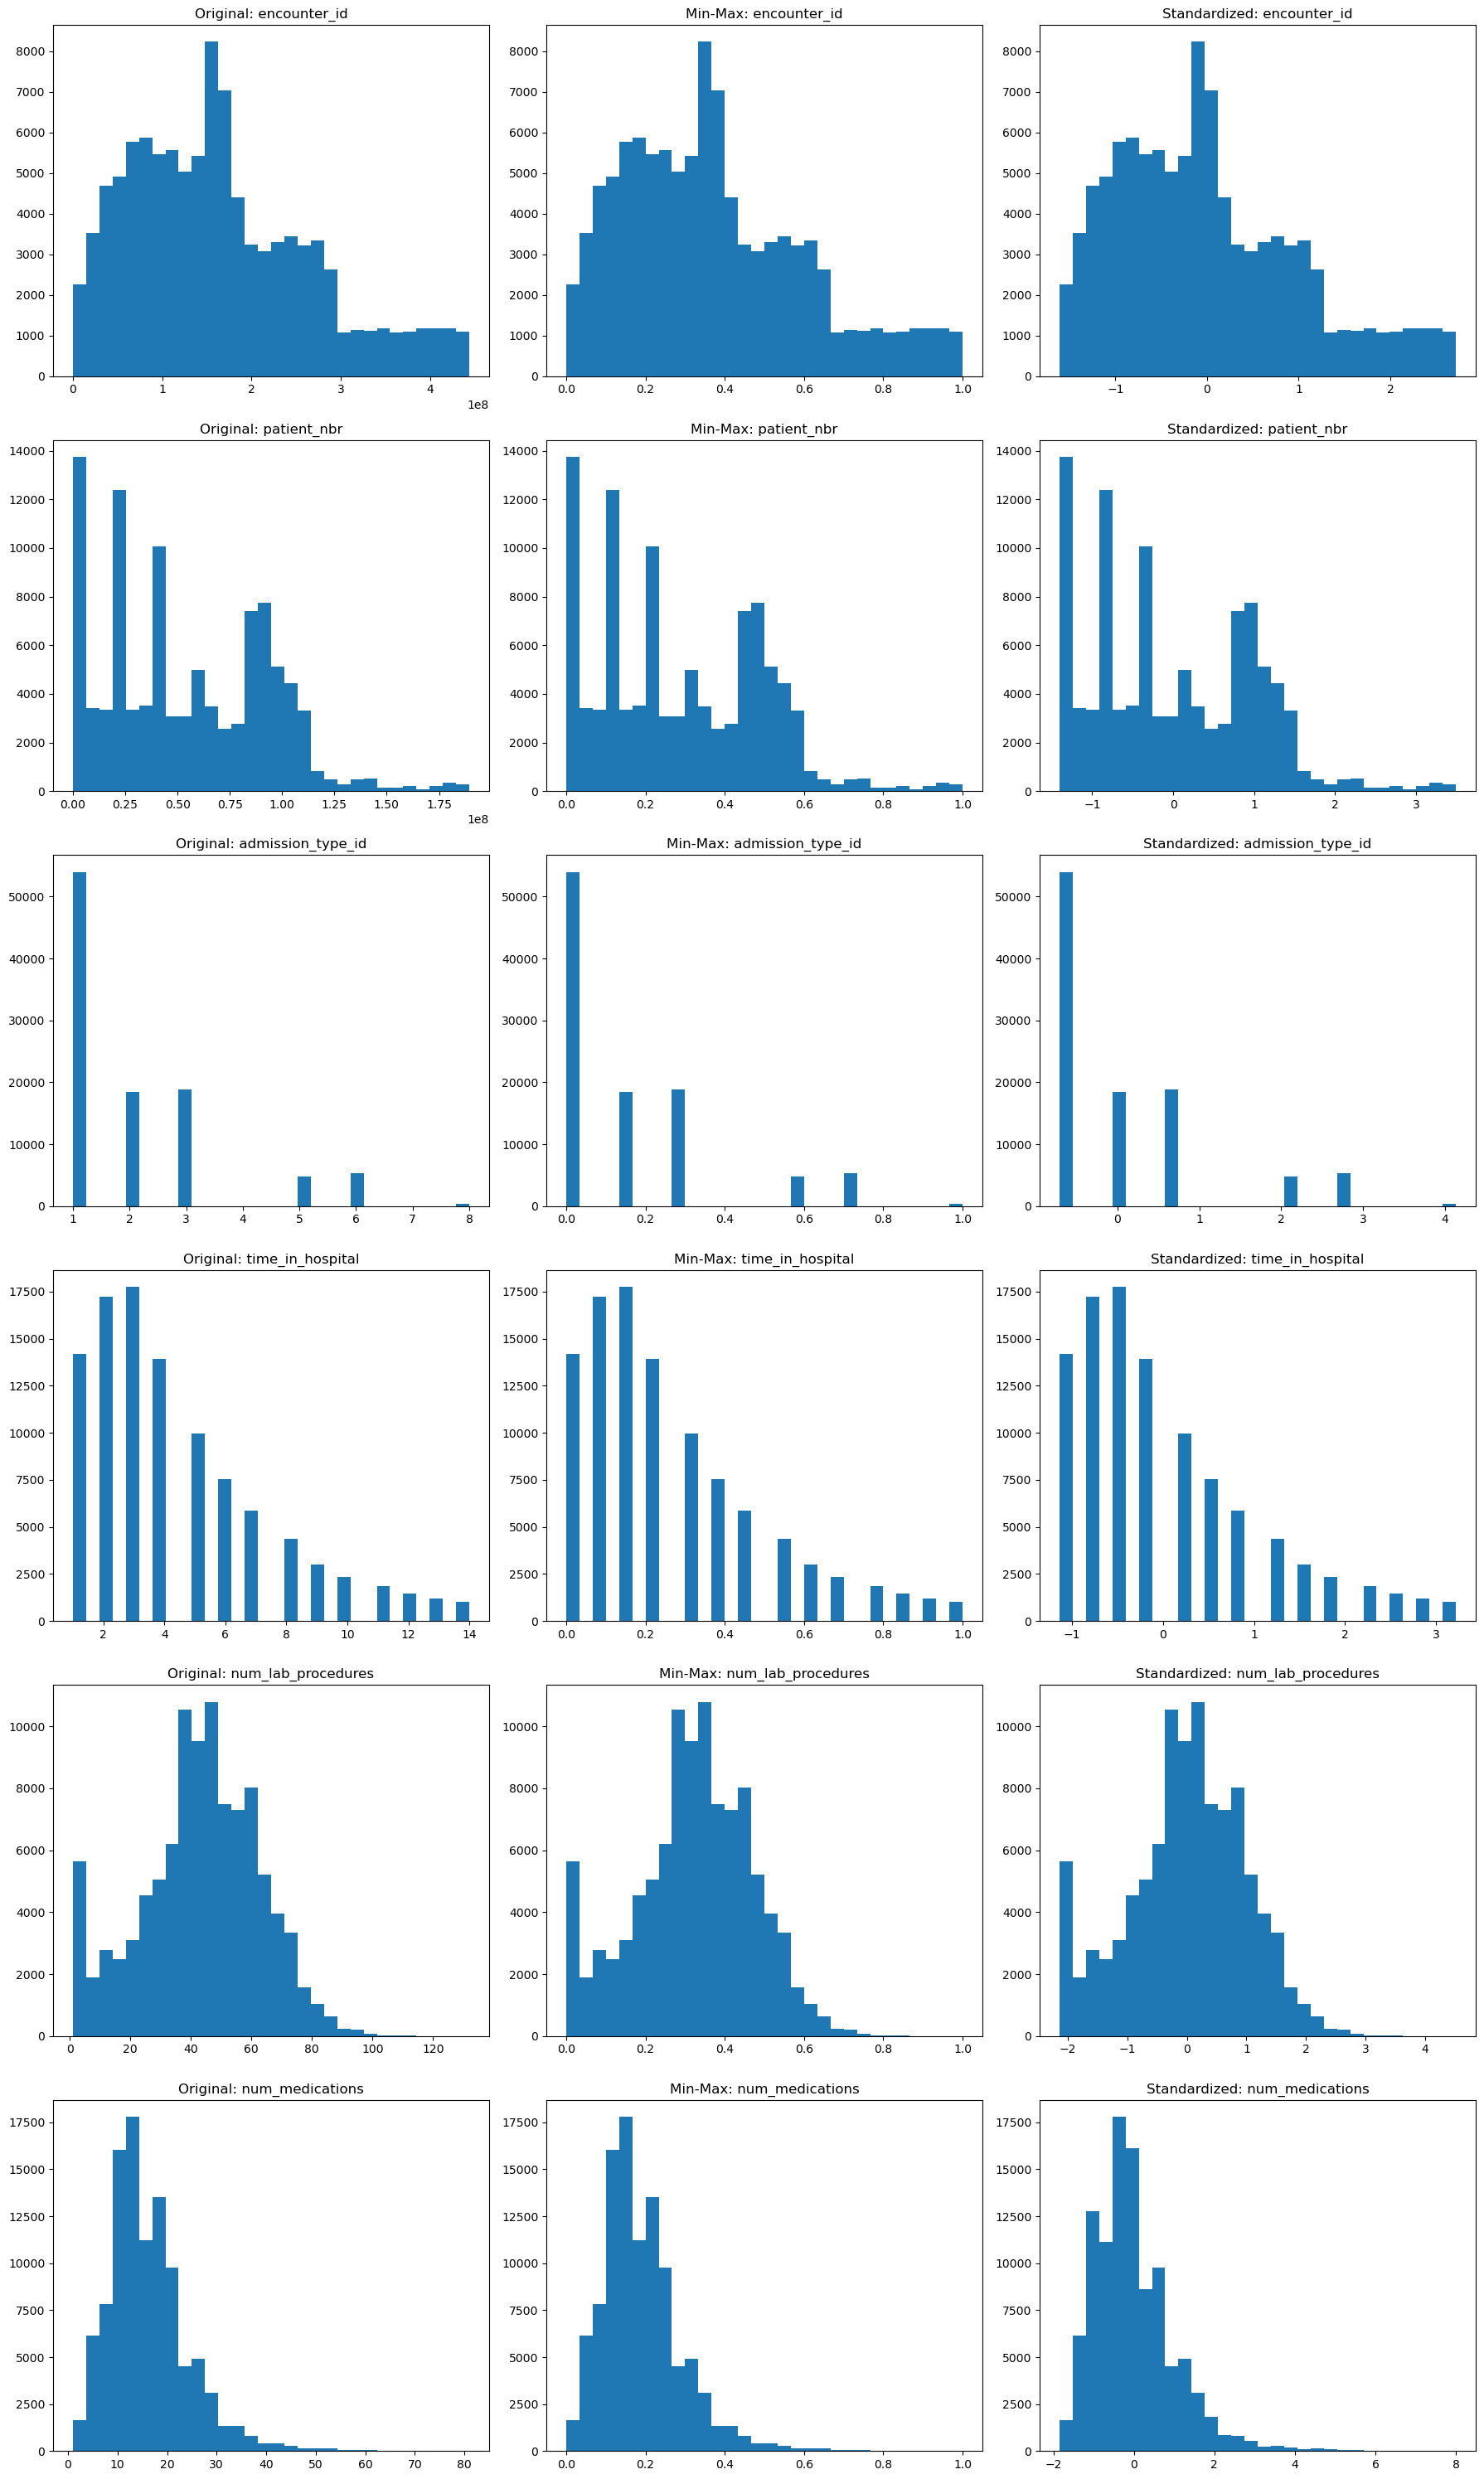

 Saved normalization comparison grid to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs\Normalization_Plots\norm_comparison_grid.png


In [12]:
# =========================
# EXTRA — NORMALIZATION COMPARISON PLOTS (Original vs Min-Max vs Standard)
# =========================
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Where to save the figures
NORM_PLOTS_DIR = os.path.join(OUTPUTS_DIR, "Normalization_Plots")
os.makedirs(NORM_PLOTS_DIR, exist_ok=True)

# 1) Decide which numeric columns to visualize
#    (put the ones you want; they must exist AND be numeric)
cols_to_compare = [c for c in [
    "encounter_id", "patient_nbr", "admission_type_id",
    "time_in_hospital", "num_lab_procedures", "num_medications"
] if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

if not cols_to_compare:
    print("No valid numeric columns found for comparison. Update 'cols_to_compare'.")
else:
    # 2) Prepare scaled versions (Min-Max and Standard) on copies of original df
    num_cols_all = [c for c in df.select_dtypes(include=[np.number]).columns]
    mm = MinMaxScaler()
    ss = StandardScaler()

    df_minmax   = df.copy()
    df_standard = df.copy()

    if num_cols_all:
        df_minmax[num_cols_all]   = mm.fit_transform(df_minmax[num_cols_all])
        df_standard[num_cols_all] = ss.fit_transform(df_standard[num_cols_all])

    # 3) Build a grid: rows = len(cols_to_compare), 3 columns (Original, Min-Max, Standard)
    import math
    n_rows = len(cols_to_compare)
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])  # ensure 2D indexing

    for i, col in enumerate(cols_to_compare):
        # Original
        ax = axes[i, 0]
        ax.hist(df[col].dropna(), bins=30)
        ax.set_title(f"Original: {col}")

        # Min-Max
        ax = axes[i, 1]
        ax.hist(df_minmax[col].dropna(), bins=30)
        ax.set_title(f"Min-Max: {col}")

        # Standardized
        ax = axes[i, 2]
        ax.hist(df_standard[col].dropna(), bins=30)
        ax.set_title(f"Standardized: {col}")

    plt.tight_layout()
    outpath = os.path.join(NORM_PLOTS_DIR, "norm_comparison_grid.png")
    plt.savefig(outpath, dpi=150)
    plt.show()
    print(" Saved normalization comparison grid to:", outpath)

In [13]:
# =========================
# STEP 2 — SELECT COLUMNS TO NORMALIZE (numeric only, exclude IDs/targets)
# =========================
exclude = set([TARGET_COL, DERIVED_TGT] + [c for c in ID_COLS if c in df.columns])
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

print("Numeric columns to scale (first 20):", num_cols[:20], "...")
print("Count:", len(num_cols))

# Basic sanity: Impute any remaining NaNs in numeric columns with median BEFORE scaling
for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

shape_note("After numeric imputation", df)

Numeric columns to scale (first 20): ['gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed'] ...
Count: 20
After numeric imputation   -> shape: (101766, 111)


In [14]:
# =========================
# STEP 3 — CHOOSE SCALER & APPLY
# =========================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Options: "standard", "minmax", "robust"
SCALER_KIND = "standard"   # <<< change here if needed

if SCALER_KIND == "standard":
    scaler = StandardScaler()
    suffix = "standard"
elif SCALER_KIND == "minmax":
    scaler = MinMaxScaler()
    suffix = "minmax"
elif SCALER_KIND == "robust":
    scaler = RobustScaler()
    suffix = "robust"
else:
    raise ValueError("SCALER_KIND must be one of: 'standard', 'minmax', 'robust'")

df_scaled = df.copy()
if num_cols:
    scaled_values = scaler.fit_transform(df_scaled[num_cols])
    df_scaled[num_cols] = scaled_values

shape_note(f"After {SCALER_KIND} scaling", df_scaled)

# OPTIONAL: save scaler statistics for reproducibility (only for standard/robust)
stats_rows = []
if hasattr(scaler, "mean_"):
    for c, mu, sd in zip(num_cols, getattr(scaler, "mean_"), getattr(scaler, "scale_", [np.nan]*len(num_cols))):
        stats_rows.append({"column": c, "mean": mu, "scale_or_std": sd})
elif isinstance(scaler, MinMaxScaler):
    for i, c in enumerate(num_cols):
        data_min = scaler.data_min_[i]
        data_max = scaler.data_max_[i]
        stats_rows.append({"column": c, "data_min": data_min, "data_max": data_max})

stats_df = pd.DataFrame(stats_rows)
if not stats_df.empty:
    stats_path = os.path.join(OUTPUTS_DIR, f"normalization_stats_{suffix}.csv")
    stats_df.to_csv(stats_path, index=False)
    print("Saved scaler stats to:", stats_path)

After standard scaling     -> shape: (101766, 111)
Saved scaler stats to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs\normalization_stats_standard.csv


In [15]:
# =========================
# STEP 4 — SAVE NORMALIZED DATASET
# =========================
out_csv = os.path.join(OUTPUTS_DIR, f"diabetic_normalized_{suffix}.csv")
df_scaled.to_csv(out_csv, index=False)
print(" Saved normalized dataset to:", out_csv)

display(df_scaled.head())


 Saved normalized dataset to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs\diabetic_normalized_standard.csv


,encounter_id,patient_nbr,readmitted,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady
0,2278392,8222157,NO,-0.927397,2.750800,4.031022,-1.169873,-1.137649,-1.295039,-0.106517,...,True,False,False,True,False,False,False,False,False,False
1,149190,55629189,>30,-0.927397,-0.708461,-0.514312,0.306482,-0.467653,1.003076,0.808384,...,False,False,True,True,False,False,False,False,False,False
2,64410,86047875,NO,-0.927397,-0.708461,-0.514312,0.306482,-0.802651,1.003076,-1.631351,...,True,False,False,True,False,False,False,False,False,False
3,500364,82442376,NO,1.078287,-0.708461,-0.514312,0.306482,-0.802651,1.003076,0.045967,...,False,False,True,True,False,False,False,False,False,False
4,16680,42519267,NO,1.078287,-0.708461,-0.514312,0.306482,-1.137649,1.003076,0.401761,...,False,True,False,True,False,False,False,False,False,False
